Iter 0, Loss: 1.2716e+01
Iter 1000, Loss: 3.5803e-02
Iter 2000, Loss: 1.5377e-02
Iter 3000, Loss: 1.2274e-02
Iter 4000, Loss: 3.2532e-03
Iter 5000, Loss: 7.5559e-04
Iter 6000, Loss: 6.0035e-04
Iter 7000, Loss: 7.3269e-04
Iter 8000, Loss: 2.8127e-04
Iter 9000, Loss: 2.5319e-04


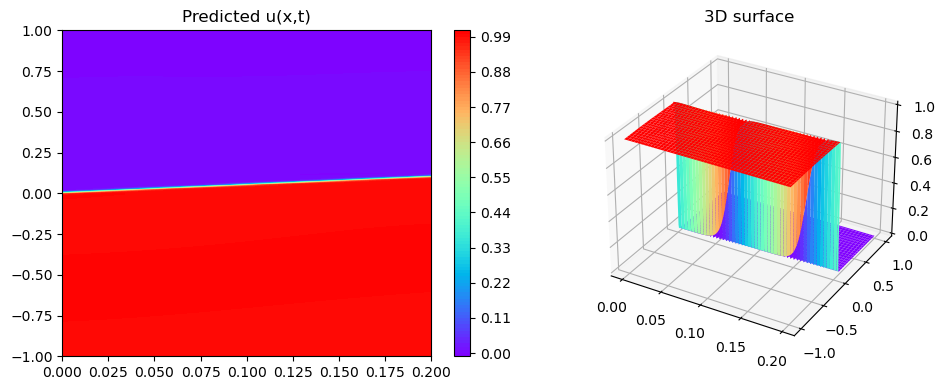

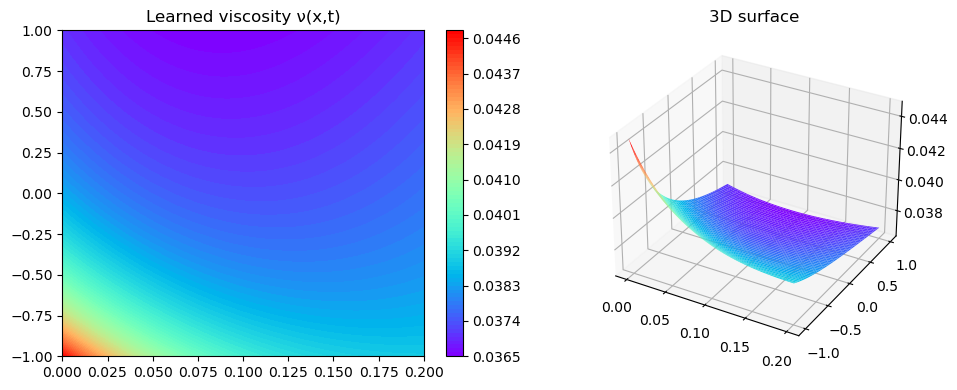

In [4]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from pyDOE import lhs

# Set seeds and device
torch.manual_seed(1234)
np.random.seed(1234)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Domain and data
Tf = 0.2
N_u, N_f = 100, 10000
lb, ub = np.array([-1.0, 0.0]), np.array([1.0, 0.2])

def gen_data():
    x = np.linspace(-1, 1, 256)[:, None]
    t = np.linspace(0, Tf, 100)[:, None]
    X, T = np.meshgrid(x, t)
    X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))

    u_ic = np.where(X_star[:, 1] == 0.0, np.where(X_star[:, 0] < 0, 1.0, 0.0), np.nan)
    u_star = np.copy(u_ic)
    u_star[np.isnan(u_star)] = 0.0
    return X_star, u_star[:, None], x, t

def lhs_sample(N, lb, ub):
    return lb + (ub - lb) * lhs(2, N)

# Viscosity network
class ViscosityNN(nn.Module):
    def __init__(self, layers, lb, ub):
        super().__init__()
        self.lb = torch.tensor(lb, dtype=torch.float32).to(device)
        self.ub = torch.tensor(ub, dtype=torch.float32).to(device)

        self.model = nn.Sequential(*[
            layer for i in range(len(layers) - 2)
            for layer in (nn.Linear(layers[i], layers[i+1]), nn.Tanh())
        ] + [nn.Linear(layers[-2], layers[-1]), nn.Softplus()])  # Ensure ν > 0

        for m in self.model:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.model((x - self.lb) / (self.ub - self.lb))

# PINN model with adaptive viscosity
class AdaptivePINN(nn.Module):
    def __init__(self, u_layers, vis_layers, lb, ub):
        super().__init__()
        self.lb = torch.tensor(lb, dtype=torch.float32).to(device)
        self.ub = torch.tensor(ub, dtype=torch.float32).to(device)

        self.u_net = nn.Sequential(*[
            layer for i in range(len(u_layers) - 2)
            for layer in (nn.Linear(u_layers[i], u_layers[i+1]), nn.Tanh())
        ] + [nn.Linear(u_layers[-2], u_layers[-1])])

        self.vis_net = ViscosityNN(vis_layers, lb, ub)

        for m in self.u_net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.u_net((x - self.lb) / (self.ub - self.lb))

    def viscosity(self, x):
        return self.vis_net(x)

    def loss(self, xu, u, xf, f_target):
        u_pred = self.forward(xu)
        loss_u = nn.MSELoss()(u_pred, u)

        xf.requires_grad_(True)
        u_f = self.forward(xf)
        f=0.5*u_f**2
        grads = autograd.grad(u_f, xf, torch.ones_like(u_f), create_graph=True)[0]
        u_x, u_t = grads[:, 0:1], grads[:, 1:2]
        grads = autograd.grad(f, xf, torch.ones_like(u_f), create_graph=True)[0]
        f_x, f_t = grads[:, 0:1], grads[:, 1:2]
        u_xx = autograd.grad(u_x, xf, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]

        ν = self.viscosity(xf)
        f_pred = u_t + f_x- ν**2 * u_xx
        loss_f = nn.MSELoss()(f_pred, f_target)
        loss_v = nn.MSELoss()(ν**2,0*f_pred)

        return loss_u + loss_f+100*loss_v

def train(model, optimizer, X_u, U_u, X_f, steps=10000):
    f_target = torch.zeros(X_f.shape[0], 1).to(device)
    for i in range(steps):
        optimizer.zero_grad()
        loss = model.loss(X_u, U_u, X_f, f_target)
        loss.backward()
        optimizer.step()
        if i % 1000 == 0:
            print(f"Iter {i}, Loss: {loss.item():.4e}")

def plot(x, t, u_pred, title='u(x,t)'):
    X, T = np.meshgrid(x, t)
    fig = plt.figure(figsize=(10, 4))
    ax1 = fig.add_subplot(121)
    cp = ax1.contourf(T, X, u_pred, 100, cmap="rainbow")
    fig.colorbar(cp, ax=ax1)
    ax1.set_title(title)
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(T, X, u_pred, cmap="rainbow")
    ax2.set_title('3D surface')
    plt.tight_layout()
    plt.show()

# Main
X_star, u_star, x, t = gen_data()

# Initial condition points
t0_indices = np.where(X_star[:, 1] == 0.0)[0]
idx_u = np.random.choice(t0_indices, N_u, replace=False)
X_u = torch.tensor(X_star[idx_u], dtype=torch.float32).to(device)
U_u = torch.tensor(u_star[idx_u], dtype=torch.float32).to(device)

# Collocation points
X_f = torch.tensor(lhs_sample(N_f, lb, ub), dtype=torch.float32).to(device)

# Model and training
model = AdaptivePINN([2, 20, 20, 20, 20, 1], [2, 20, 20, 20, 1], lb, ub).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
train(model, optimizer, X_u, U_u, X_f, steps=10000)

# Inference and plotting
X_test = torch.tensor(X_star, dtype=torch.float32).to(device)
u_pred = model.forward(X_test).cpu().detach().numpy().reshape(len(t), len(x))
plot(x, t, u_pred, title='Predicted u(x,t)')

# Plot learned viscosity
nu_pred = model.viscosity(X_test).cpu().detach().numpy().reshape(len(t), len(x))
plot(x, t, nu_pred, title='Learned viscosity ν(x,t)')


In [5]:

X,T=np.meshgrid(x,t)
data1=np.vstack([X.flatten(),T.flatten(),u_pred.flatten()])
data1=data1.T
np.savetxt('burg_con_pinn.dat',data1)

In [6]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_solution_with_shock(x, t, u_pred):
    fig, ax = plt.subplots(figsize=(8, 4))
    line, = ax.plot([], [], 'b-', lw=2, label='PINN Prediction')
    shock_line = ax.axvline(x=0, color='r', linestyle='--', label='Exact Shock')
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(u_pred.min() - 0.1, u_pred.max() + 0.1)
    ax.set_xlabel("x")
    ax.set_ylabel("u(x,t)")
    ax.set_title("Burgers' Equation: u(x,t) over time")
    ax.legend()

    def init():
        line.set_data([], [])
        shock_line.set_xdata(0)
        return line, shock_line

    def update(frame):
        line.set_data(x, u_pred[frame])
        shock_pos = 0.5 * t[frame, 0]
        shock_line.set_xdata(shock_pos)
        ax.set_title(f"t = {t[frame, 0]:.4f}, Shock at x = {shock_pos:.4f}")
        return line, shock_line

    ani = FuncAnimation(fig, update, frames=len(t), init_func=init, blit=True)
    plt.close(fig)
    return ani

# Display the animation with the shock comparison
ani = animate_solution_with_shock(x.flatten(), t, u_pred)
HTML(ani.to_jshtml())
